In [2]:
import pandas as pd
import numpy as np
import warnings
from astropy.io import fits
from astropy import modeling
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from astropy.constants import c
from astropy.modeling import models
from astropy import units as u
from specutils.spectra import Spectrum1D, SpectralRegion
from specutils.fitting import fit_lines, fit_generic_continuum
from specutils.analysis import equivalent_width
from specutils.fitting import find_lines_derivative
from astropy.stats import sigma_clip
from astropy.table import Table
import os
import sys
from PyAstronomy import pyasl
from PyAstronomy.pyasl import fastRotBroad, rotBroad, specAirVacConvert, airtovac2, equidistantInterpolation
from scipy.interpolate import interp1d
# from starfused import StellarModel

In [22]:
path = '/Users/brooklyngustaf/Desktop/research/Brooklyn_NEID_spectra_project/l2fits/'
folder_path = path + 'TIC_168707425'

def get_spectral_order(fits_file, echelle_order):
    all_fluxes = []
    all_wavelengths = []
    # SN_list = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".fits"):
            file_path = os.path.join(folder_path, filename)
            with fits.open(file_path) as hdul:
                header = dict(hdul[12].header['*DVR\D+|*RV\D+|*CCFJDSUM*|ccfrvmod|'].items())
                header.update(dict(hdul[0].header['OBJECT*|*DATE-OBS|*SCI-OBJ|*QRA|*QDEC|OBSJD|*QSPT'].items()))
                header.update({'rv_correction':hdul[0].header[f'SSBRV{173 - echelle_order:03d}']})
                SN = hdul[0].header['EXTSNR']
                activity = Table(hdul[13].data)
                # SN_list.append(SN)
                SN_wavelength=hdul[0].header['EXTSNRWL']
                c_kms = c.to('km/s').value  # Speed of light in km/s
                rv = header['CCFRVMOD'] - header['rv_correction'] #correcting from heliocentric rv
                wave = (hdul[7].data[echelle_order] * u.AA) / (1 + (rv / c_kms)) #doppler shift correction
                flux = hdul[1].data[echelle_order] 
                all_wavelengths.append(wave) 
                all_fluxes.append(flux)
                # print(rv)
                # print(SN)
                # print(SN_wavelength)
                # print(activity)

    # Convert to arrays
    all_fluxes = np.array(all_fluxes)
    all_wavelengths = np.array(all_wavelengths)

    # choose reference grid (e.g., first spectrum)
    wavelengths = all_wavelengths[0]

    resampled_fluxes = []

    for wave, flux in zip(all_wavelengths, all_fluxes):
        interp_flux = np.interp(wavelengths, wave, flux)
        resampled_fluxes.append(interp_flux)

    flux = np.mean(resampled_fluxes, axis=0)



    return wavelengths, flux, header

def fit_spectrum(wavelengths, flux, poly_degree=10, n_iter=6, sigma=2.0):

    # --- Remove NaNs / Infs ---
    valid = np.isfinite(wavelengths) & np.isfinite(flux)
    lambda_valid = wavelengths[valid]
    flux_valid = flux[valid]

    # Optional: small offset if needed
    flux_valid = flux_valid + 10

    # --- Initial mask (start with everything) ---
    mask = np.ones(len(lambda_valid), dtype=bool)

    fit_g = modeling.fitting.LevMarLSQFitter()

    for _ in range(n_iter):

        # Fit polynomial to currently accepted pixels
        p_init = models.Polynomial1D(degree=poly_degree)
        continuum_fit = fit_g(p_init,
                              lambda_valid[mask],
                              flux_valid[mask])

        # Compute residuals
        model_flux = continuum_fit(lambda_valid)
        residuals = flux_valid - model_flux

        # Estimate scatter robustly
        std = np.std(residuals[mask])

        # Reject only absorption features (negative residuals)
        new_mask = residuals > -sigma * std

        # Stop if mask stops changing
        if np.all(new_mask == mask):
            break

        mask = new_mask

    # --- Final continuum ---
    continuum = continuum_fit(lambda_valid)

    # --- Normalize ---
    flux_norm = flux_valid / continuum

    return continuum_fit, lambda_valid, flux_valid, flux_norm

<>:12: SyntaxWarning: invalid escape sequence '\D'
<>:12: SyntaxWarning: invalid escape sequence '\D'
/var/folders/ch/bcxs_6vj0jj86m8mfdlxqyhw0000gn/T/ipykernel_66818/1987701231.py:12: SyntaxWarning: invalid escape sequence '\D'
  header = dict(hdul[12].header['*DVR\D+|*RV\D+|*CCFJDSUM*|ccfrvmod|'].items())


In [24]:
wavelengths, flux, header = get_spectral_order(folder_path, 80)
continuum_fit, lambda_valid, flux_valid, flux_norm = fit_spectrum(wavelengths, flux)

# Convert Astropy Quantity to plain Angstrom values if needed
wave = lambda_valid.value if hasattr(lambda_valid, "value") else lambda_valid

# If you don't have uncertainties:
err = np.zeros_like(flux_norm)

data = np.column_stack([wave/10, flux_norm, err])

np.savetxt(
    "TIC_168707425_order80.txt",
    data,
    header="waveobs flux err",
    comments="",
    fmt="%.10f"
)

[2026-06-05 13:29:04,222] [WARNING] [logger:_showwarning:244]: Model is linear in parameters; consider using linear fitting methods.


In [39]:
df = pd.read_csv('/Users/brooklyngustaf/Desktop/research/Brooklyn_NEID_spectra_project/GOLD_WD_binaries_forDon_APOGEE_GAIA_TIC_2MASS_StarHorse1.csv')

In [43]:
tic_id = 435238791

def get_params(df, tic_id):
    star = df[df["TIC"] == tic_id].iloc[0]
    teff = star["Teff_1"]
    logg = star["logg_1"]
    MH = star["M_H"]
    vsini = star["VSINI"]

    return star, teff, logg, MH, vsini

            TIC  Teff_1  s_Teff  logg_1  s_logg      M_H   M_H_ERR      VSINI  \
1408  435238791  4405.0   125.0  4.5465  0.1011 -0.18798  0.007771  10.904357   

         FE_H  
1408 -0.19093  


In [28]:
import os
import sys
import numpy as np
import logging
import multiprocessing
from multiprocessing import Pool

ispec_dir = "/Users/brooklyngustaf/Desktop/research/iSpec_v20230804"
sys.path.insert(0, os.path.abspath(ispec_dir))

import ispec

def synthesize_spectrum(code="spectrum"):
    #--- Synthesizing spectrum -----------------------------------------------------
    # Parameters
    teff = teff
    logg = logg
    MH = MH
    alpha = ispec.determine_abundance_enchancements(MH)
    microturbulence_vel = ispec.estimate_vmic(teff, logg, MH)
    macroturbulence = ispec.estimate_vmac(teff, logg, MH)
    vsini = vsini
    limb_darkening_coeff = 0.0
    resolution = 110000
    wave_step = 0.001

    # Wavelengths to synthesis
    #regions = ispec.read_segment_regions(ispec_dir + "/input/regions/fe_lines_segments.txt")
    regions = None
    wave_base = 843.0 #region
    wave_top = 869.0


    # Selected model amtosphere, linelist and solar abundances
    #model = ispec_dir + "/input/atmospheres/MARCS/"
    model = ispec_dir + "/input/atmospheres/MARCS.GES/"
    #model = ispec_dir + "/input/atmospheres/MARCS.APOGEE/"
    #model = ispec_dir + "/input/atmospheres/ATLAS9.APOGEE/"
    #model = ispec_dir + "/input/atmospheres/ATLAS9.Castelli/"
    #model = ispec_dir + "/input/atmospheres/ATLAS9.Kurucz/"
    #model = ispec_dir + "/input/atmospheres/ATLAS9.Kirby/"

    atomic_linelist_file = ispec_dir + "/input/linelists/transitions/VALD.300_1100nm/atomic_lines.tsv"
    #atomic_linelist_file = ispec_dir + "/input/linelists/transitions/VALD.1100_2400nm/atomic_lines.tsv"
    # atomic_linelist_file = ispec_dir + "/input/linelists/transitions/GESv6_atom_hfs_iso.420_920nm/atomic_lines.tsv"
    #atomic_linelist_file = ispec_dir + "/input/linelists/transitions/GESv6_atom_nohfs_noiso.420_920nm/atomic_lines.tsv"

    isotope_file = ispec_dir + "/input/isotopes/SPECTRUM.lst"

    # Load chemical information and linelist
    atomic_linelist = ispec.read_atomic_linelist(atomic_linelist_file, wave_base=wave_base, wave_top=wave_top)
    atomic_linelist = atomic_linelist[atomic_linelist['theoretical_depth'] >= 0.01] # Select lines that have some minimal contribution in the sun

    isotopes = ispec.read_isotope_data(isotope_file)

    if "ATLAS" in model:
        solar_abundances_file = ispec_dir + "/input/abundances/Grevesse.1998/stdatom.dat"
    else:
        # MARCS
        solar_abundances_file = ispec_dir + "/input/abundances/Grevesse.2007/stdatom.dat"
    #solar_abundances_file = ispec_dir + "/input/abundances/Asplund.2005/stdatom.dat"
    #solar_abundances_file = ispec_dir + "/input/abundances/Asplund.2009/stdatom.dat"
    #solar_abundances_file = ispec_dir + "/input/abundances/Anders.1989/stdatom.dat"

    # Load model atmospheres
    modeled_layers_pack = ispec.load_modeled_layers_pack(model)
    # Load SPECTRUM abundances
    solar_abundances = ispec.read_solar_abundances(solar_abundances_file)

    ## Custom fixed abundances
    #fixed_abundances = ispec.create_free_abundances_structure(["C", "N", "O"], chemical_elements, solar_abundances)
    #fixed_abundances['Abund'] = [-3.49, -3.71, -3.54] # Abundances in SPECTRUM scale (i.e., x - 12.0 - 0.036) and in the same order ["C", "N", "O"]
    ## No fixed abundances
    fixed_abundances = None

    # Validate parameters
    if not ispec.valid_atmosphere_target(modeled_layers_pack, {'teff':teff, 'logg':logg, 'MH':MH, 'alpha':alpha}):
        msg = "The specified effective temperature, gravity (log g) and metallicity [M/H] \
                fall out of theatmospheric models."
        print(msg)

    # Prepare atmosphere model
    atmosphere_layers = ispec.interpolate_atmosphere_layers(modeled_layers_pack, {'teff':teff, 'logg':logg, 'MH':MH, 'alpha':alpha}, code=code)

    # Synthesis
    synth_spectrum = ispec.create_spectrum_structure(np.arange(wave_base, wave_top, wave_step))
    synth_spectrum['flux'] = ispec.generate_spectrum(synth_spectrum['waveobs'], \
            atmosphere_layers, teff, logg, MH, alpha, atomic_linelist, isotopes, solar_abundances, \
            fixed_abundances, microturbulence_vel = microturbulence_vel, \
            macroturbulence=macroturbulence, vsini=vsini, limb_darkening_coeff=limb_darkening_coeff, \
            R=resolution, regions=regions, verbose=1,
            code=code)
    ##--- Save spectrum ------------------------------------------------------------
    logging.info("Saving spectrum...")
    synth_filename = (f"TIC_{tic_id}_spectrum_marcs_vald_"f"{int(wave_base)}_{int(wave_top)}_.fits")
    ispec.write_spectrum(synth_spectrum, synth_filename)

In [29]:
synthesize_spectrum(code="spectrum")

*********************************************************************
Not optimized version loaded!
*********************************************************************
*********************************************************************
Not optimized version loaded!
*********************************************************************
*********************************************************************
Not optimized version loaded!
*********************************************************************

SPECTRUM, a Stellar Spectral Synthesis Program
(C) Richard O. Gray 1992 - 2010 Version 2.76e
May 3, 2010
* Linked to Python by Sergi Blanco Cuaresma - February 2012

Integrated Disk mode (normalized Intensity)

Isotopes enabled
Teff =   4405 log(g) =  4.55 [M/H] = -0.19

Calculating Partition Functions for all species for all levels
Completed level 0  1  2  3  4  5  6  7  8  9  10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  

[2026-06-09 12:10:15,657] [INFO] [spectrum:__convolve_spectrum:789]: Spectra convolved!
[2026-06-09 12:10:15,826] [INFO] [2955023976:synthesize_spectrum:94]: Saving spectrum...


In [24]:
with fits.open('/Users/brooklyngustaf/Desktop/research/code/spectrum_marcs_vald_843_859_.fits') as hdul:
    hdul.info()
    print(hdul[0].header)
    flux = hdul[0].data 
    header = hdul[0].header

    n = header["NAXIS1"]
    crval = header["CRVAL1"]
    cdelt = header["CDELT1"]
    crpix = header["CRPIX1"]

wave = crval + (np.arange(n) + 1 - crpix) * cdelt

Filename: /Users/brooklyngustaf/Desktop/research/code/spectrum_marcs_vald_843_859_.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      13   (16200,)   float32   
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                  -32 / array data type                                NAXIS   =                    1 / number of array dimensions                     NAXIS1  =                16200                                                  ORIGIN  = 'iSpec   '                                                            UTCSAVED= '2026-06-08 19:19:07'                                                 CUNIT1  = 'NM      '                                                            CTYPE1  = 'AWAV    '                                                            CDELT1  = 0.000999999999976353                                                  CRVAL1  =                843.1                                    

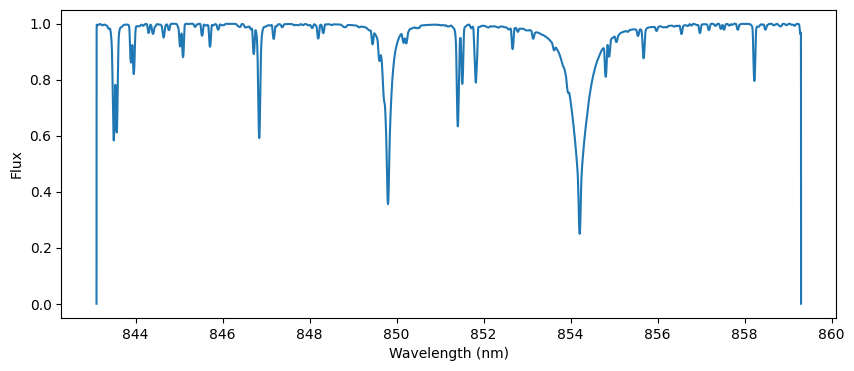

In [25]:
plt.figure(figsize=(10,4))
plt.plot(wave, flux)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Flux")
plt.show()